"""
dl_project.ipynb - 당뇨병성 망막병증(Diabetic Retinopathy) 분류
APTOS 2019 Blindness Detection Dataset

실행 흐름:
  1. 라이브러리 임포트
  2. 데이터셋 압축 해제 및 경로 설정
  3. 데이터 로딩 및 정보 확인
  4. 데이터 전처리 (Ben Graham 기법)
  5. 모델 정의 및 데이터로더 구성
  6. 손실함수 / 옵티마이저 설정
  7. 모델 학습 (Transfer Learning + Fine-tuning)
  8. 성능 지표 확인 (QWK, Classification Report, Confusion Matrix)
  9. Grad-CAM 시각화
  10. Baseline(전처리 전) 성능 비교
"""

In [1]:
import os

# 1. 파일에서 확인한 정보 입력
os.environ['KAGGLE_USERNAME'] = "heejeongpark316"
os.environ['KAGGLE_KEY'] = "e2633756d0f9c7adeeef3cd6f2e90c76"

# 2. 인증 테스트 (이제는 401 에러 없이 리스트가 뜰 거예요!)
print("--- 인증 시도 중 ---")
!kaggle competitions list

# 3. APTOS 2019 데이터셋 다운로드
!kaggle competitions download -c aptos2019-blindness-detection

--- 인증 시도 중 ---
ref                                                                            deadline             category         reward  teamCount  userHasEntered  
-----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3  2026-04-15 23:59:00  Featured  2,207,152 Usd       3964           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge    2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                             2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                     2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detecti

In [2]:
import zipfile

# 압축 해제 (시간이 조금 걸릴 수 있어요)
with zipfile.ZipFile('aptos2019-blindness-detection.zip', 'r') as zip_ref:
    zip_ref.extractall('aptos_data')

print("모든 데이터 준비 완료! 'aptos_data' 폴더를 확인해 보세요.")

모든 데이터 준비 완료! 'aptos_data' 폴더를 확인해 보세요.


In [3]:
# ============================================================
# STEP 1. 라이브러리 임포트
# ============================================================
import os
import pandas as pd
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score


In [8]:
# ============================================================
# STEP 2. 데이터셋 압축 해제 및 경로 설정
# ============================================================

# ── 경로 설정 ──────────────────────────────────────────────
BASE_PATH   = '/content/aptos_data'
TRAIN_CSV   = os.path.join(BASE_PATH, 'train.csv')
TEST_CSV    = os.path.join(BASE_PATH, 'test.csv')
IMAGE_DIR   = os.path.join(BASE_PATH, 'train_images')   # 원본 학습 이미지
TEST_DIR    = os.path.join(BASE_PATH, 'test_images')    # 원본 테스트 이미지
SAVE_DIR    = os.path.join(BASE_PATH, 'preprocessed')   # 전처리 완료 이미지 저장 위치

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# ── 하이퍼파라미터 (Google Colab T4 기준) ──────────────────
BATCH_SIZE = 64       # T4 VRAM 16GB → 64까지 안정적으로 사용 가능
LR         = 0.001    # 배치 크기 증가에 맞춰 학습률도 상향 (선형 스케일링 법칙)
EPOCHS     = 50       # T4 속도라면 30에폭 이상도 부담 없음, Early Stopping으로 자동 조기 종료
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {DEVICE}")


사용 디바이스: cuda



전체 데이터 수: 3662장

===[ info ]===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    3662 non-null   object
 1   diagnosis  3662 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 57.3+ KB
None

===[ describe ]===
         diagnosis
count  3662.000000
mean      1.126980
std       1.298409
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       4.000000

===[ head ]===
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

===[ 클래스별 분포 ]===
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


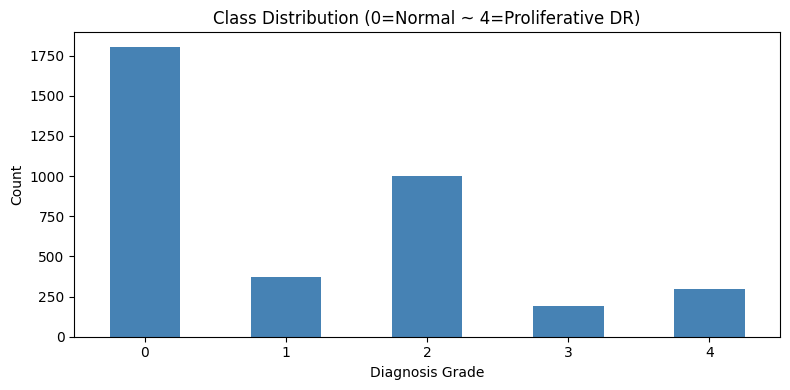

In [9]:
# ============================================================
# STEP 3. 데이터 로딩 및 정보 확인
# ============================================================

df = pd.read_csv(TRAIN_CSV)

print(f"\n전체 데이터 수: {len(df)}장")
print("\n===[ info ]===")
print(df.info())
print("\n===[ describe ]===")
print(df.describe())
print("\n===[ head ]===")
print(df.head())
print("\n===[ 클래스별 분포 ]===")
print(df['diagnosis'].value_counts().sort_index())

# 클래스 분포 시각화
plt.figure(figsize=(8, 4))
df['diagnosis'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Class Distribution (0=Normal ~ 4=Proliferative DR)')
plt.xlabel('Diagnosis Grade')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# STEP 4. 데이터 전처리
#
# 전처리 파이프라인:
#   원본 이미지 (.png)
#         ↓
#   ① BGR → RGB 색상 변환
#         ↓
#   ② 검은 여백 자동 크롭 (Auto-Crop)
#         ↓
#   ③ 패딩으로 정사각형 비율 맞춤 (안구 왜곡 방지)
#         ↓
#   ④ 224×224 리사이즈
#         ↓
#   ⑤ Ben Graham 기법으로 혈관·병변 강조
#         ↓
#   저장 (RGB → BGR 변환 후 .png)
# ============================================================

def preprocess_eye_image_minimal(path, img_size=300):
    """
    최소 전처리 전략:
    1. 검은 여백 제거 (Auto-Crop)
    2. 비율 보존 (Padding)
    3. 크기 조정 (Resize)
    * Ben Graham 필터는 원본 색감 보존을 위해 제거함.
    """
    image = cv2.imread(path)
    if image is None: return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # ① Auto-Crop: 실제 안구 영역만 추출
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    mask = gray > 10
    image = image[np.ix_(mask.any(1), mask.any(0))]

    # ② Padding: 가로세로 비율을 유지하며 정사각형 만들기 (왜곡 방지)
    h, w, _ = image.shape
    if h > w:
        pad = (h - w) // 2
        image = cv2.copyMakeBorder(image, 0, 0, pad, pad, cv2.BORDER_CONSTANT, value=[0,0,0])
    else:
        pad = (w - h) // 2
        image = cv2.copyMakeBorder(image, pad, pad, 0, 0, cv2.BORDER_CONSTANT, value=[0,0,0])

    # ③ Resize: 모델 입력 크기에 맞춤
    image = cv2.resize(image, (img_size, img_size))

    return image


# 전체 이미지 전처리 및 저장
# 데이터 셔플 후 전처리
df_final = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_final.to_csv(os.path.join(BASE_PATH, 'train_all.csv'), index=False)
print(f"\n전체 데이터 {len(df_final)}장에 대해 전처리를 진행합니다...")

error_count = 0
for _, row in tqdm(df_final.iterrows(), total=len(df_final)):
    img_path  = os.path.join(IMAGE_DIR, row['id_code'] + '.png')
    save_path = os.path.join(SAVE_DIR,  row['id_code'] + '.png')

    if os.path.exists(img_path):
        try:
            processed = preprocess_eye_image_minimal(img_path)
            cv2.imwrite(save_path, cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))
        except Exception as e:
            print(f"  [Error] {img_path}: {e}")
            error_count += 1

print(f"\n전처리 완료! 저장 경로: {SAVE_DIR}  (오류: {error_count}건)")



전체 데이터 3662장에 대해 전처리를 진행합니다...


100%|██████████| 3662/3662 [10:22<00:00,  5.89it/s]


전처리 완료! 저장 경로: /content/aptos_data/preprocessed  (오류: 0건)


In [21]:
# ============================================================
# APTOSDataset 클래스 정의
# (STEP 5 모델 비교와 STEP 6 본 학습 모두에서 공통으로 사용)
# ============================================================

class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.df.iloc[idx, 0] + '.png')
        image    = Image.open(img_name).convert('RGB')
        label    = int(self.df.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label


  모델 비교 시작 (각 5에폭, 빠른 사전 비교)

▶ EfficientNet-B3 학습 중...


/tmp/ipykernel_1134/2032502591.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/2032502591.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [EfficientNet-B3] Epoch 1/5 | Train Loss: 1.1304 | Val Loss: 0.9176 | QWK: 0.6988


/tmp/ipykernel_1134/2032502591.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/2032502591.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [EfficientNet-B3] Epoch 2/5 | Train Loss: 0.8892 | Val Loss: 0.8016 | QWK: 0.7514


...

  [ResNet-50] Epoch 3/5 | Train Loss: 0.5758 | Val Loss: 0.4523 | QWK: 0.8891


/tmp/ipykernel_1134/2032502591.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/2032502591.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [ResNet-50] Epoch 4/5 | Train Loss: 0.4570 | Val Loss: 0.4450 | QWK: 0.8940


/tmp/ipykernel_1134/2032502591.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/2032502591.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  [ResNet-50] Epoch 5/5 | Train Loss: 0.4122 | Val Loss: 0.4710 | QWK: 0.8885
  [ResNet-50] GPU 메모리 해제 완료


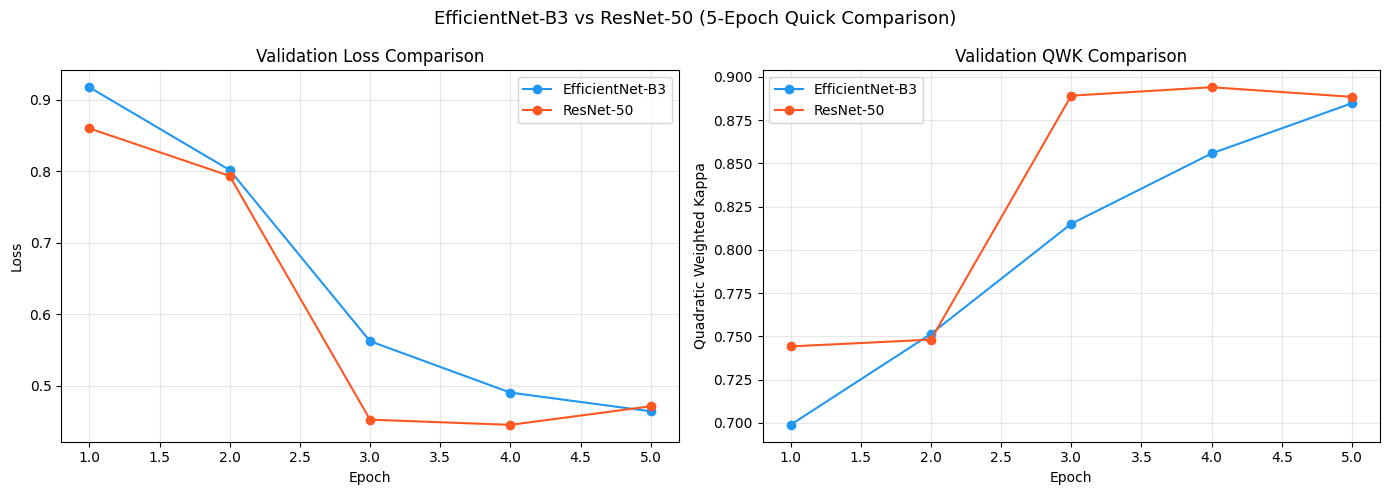


========== 모델 비교 결과 요약 ==========
  EfficientNet-B3      | 최종 Val QWK: 0.8848
  ResNet-50            | 최종 Val QWK: 0.8885

✅ 선택된 모델: ResNet-50  (QWK: 0.8885)



In [22]:
# ============================================================
# STEP 5. 모델 비교 (EfficientNet-B3 vs ResNet-50)
#
# 전략: 두 모델을 동일한 조건(5에폭, 소규모 빠른 학습)으로 먼저 비교한 뒤
#       QWK 점수가 더 높은 모델을 STEP 6 이후의 본 학습에 사용합니다.
#
# ※ 이 셀은 STEP 4(전처리 완료) 직후 ~ STEP 6(본 학습 설정) 직전에 위치합니다.
# ============================================================

COMPARE_EPOCHS = 5    # 빠른 비교를 위한 짧은 학습 (5에폭)
COMPARE_LR     = 0.001

# ── 비교용 공통 Transform (본 학습과 동일) ───────────────────
_train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
_val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── 비교용 데이터 분할 (본 학습과 동일한 seed) ──────────────
_df_all = pd.read_csv(os.path.join(BASE_PATH, 'train_all.csv'))
_train_df, _val_df = train_test_split(
    _df_all, test_size=0.2, stratify=_df_all['diagnosis'], random_state=42
)

_train_loader = DataLoader(
    APTOSDataset(_train_df, SAVE_DIR, _train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
_val_loader = DataLoader(
    APTOSDataset(_val_df, SAVE_DIR, _val_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

# ── 비교 대상 모델 2종 정의 ──────────────────────────────────
def build_efficientnet_b3():
    """EfficientNet-B3: 경량 + 높은 정확도, 의료 영상에서 강점"""
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, 5)
    return m.to(DEVICE)

def build_resnet50():
    """ResNet-50: 안정적인 수렴, 전이학습 벤치마크 표준"""
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 5)
    return m.to(DEVICE)

# ── 공통 손실함수 (비교용 간소화: CrossEntropy만 사용) ────────
_ce = nn.CrossEntropyLoss()

# ── 비교 학습 함수 ────────────────────────────────────────────
def run_comparison(name, model, train_loader, val_loader, epochs, lr):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler    = torch.amp.GradScaler('cuda')

    # Head만 먼저 학습 (Backbone 고정)
    if hasattr(model, 'classifier'):          # EfficientNet 계열
        for p in model.parameters():      p.requires_grad = False
        for p in model.classifier.parameters(): p.requires_grad = True
    else:                                      # ResNet 계열
        for p in model.parameters():      p.requires_grad = False
        for p in model.fc.parameters():   p.requires_grad = True

    history = {'train_loss': [], 'val_loss': [], 'val_qwk': []}

    for epoch in range(epochs):
        # 2에폭부터 전체 파인튜닝 (짧은 비교 학습이므로 빠르게 해제)
        if epoch == 2:
            for p in model.parameters():
                p.requires_grad = True
            for pg in optimizer.param_groups:
                pg['lr'] = lr * 0.1

        # Train
        model.train()
        t_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                out  = model(imgs)
                loss = _ce(out, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            t_loss += loss.item() * imgs.size(0)

        # Validation
        model.eval()
        v_loss, preds_list, labels_list = 0.0, [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                with torch.cuda.amp.autocast():
                    out  = model(imgs)
                    loss = _ce(out, labels)
                v_loss += loss.item() * imgs.size(0)
                _, p = torch.max(out, 1)
                preds_list.extend(p.cpu().numpy())
                labels_list.extend(labels.cpu().numpy())

        avg_t = t_loss / len(train_loader.dataset)
        avg_v = v_loss / len(val_loader.dataset)
        qwk   = cohen_kappa_score(labels_list, preds_list, weights='quadratic')
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['val_qwk'].append(qwk)
        print(f"  [{name}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_t:.4f} | Val Loss: {avg_v:.4f} | QWK: {qwk:.4f}")

    return history

import gc

# ── 두 모델 순차 비교 학습 ────────────────────────────────────
# 모델 객체를 딕셔너리에 저장하지 않고, 학습 직후 GPU에서 해제하여 OOM 방지
print("\n" + "="*60)
print("  모델 비교 시작 (각 5에폭, 빠른 사전 비교)")
print("="*60)

comparison_results = {}
for model_name, build_fn in [('EfficientNet-B3', build_efficientnet_b3),
                              ('ResNet-50',       build_resnet50)]:
    print(f"\n▶ {model_name} 학습 중...")
    cand_model = build_fn()   # 루프 안에서 생성 → 직후 해제 가능
    hist = run_comparison(
        model_name, cand_model,
        _train_loader, _val_loader,
        COMPARE_EPOCHS, COMPARE_LR
    )
    comparison_results[model_name] = {
        # 모델 객체는 저장하지 않음 → GPU 레퍼런스 카운트 0으로 만들어야 해제됨
        'history'  : hist,
        'final_qwk': hist['val_qwk'][-1],
    }
    # 비교 학습 종료 후 즉시 GPU 메모리 반환
    del cand_model
    torch.cuda.empty_cache()
    gc.collect()
    print(f"  [{model_name}] GPU 메모리 해제 완료")

# ── 비교 결과 시각화 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, COMPARE_EPOCHS + 1)
colors   = {'EfficientNet-B3': '#2196F3', 'ResNet-50': '#FF5722'}

for name, res in comparison_results.items():
    axes[0].plot(epochs_x, res['history']['val_loss'],
                 label=name, color=colors[name], marker='o')
    axes[1].plot(epochs_x, res['history']['val_qwk'],
                 label=name, color=colors[name], marker='o')

axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation QWK Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Quadratic Weighted Kappa')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('EfficientNet-B3 vs ResNet-50 (5-Epoch Quick Comparison)', fontsize=13)
plt.tight_layout()
plt.show()

# ── 최종 비교 요약 및 모델 자동 선택 ─────────────────────────
print("\n========== 모델 비교 결과 요약 ==========")
for name, res in comparison_results.items():
    print(f"  {name:20s} | 최종 Val QWK: {res['final_qwk']:.4f}")

best_model_name = max(comparison_results, key=lambda k: comparison_results[k]['final_qwk'])
print(f"\n✅ 선택된 모델: {best_model_name}  (QWK: {comparison_results[best_model_name]['final_qwk']:.4f})")
print("=========================================\n")


In [23]:
# ============================================================
# STEP 6. 최종 모델 선정 및 데이터로더 구성
#
# STEP 5 비교 결과를 바탕으로 QWK가 높은 모델을 자동으로 선택합니다.
# 선택된 모델은 가중치를 초기화(재로드)하여 본격 학습을 시작합니다.
# ============================================================

# ── STEP 5 결과로 모델 자동 선택 후 가중치 초기화 ─────────────
# 비교 학습(5에폭)으로 오염된 가중치를 버리고 ImageNet 가중치로 다시 시작
if best_model_name == 'EfficientNet-B3':
    model = build_efficientnet_b3()
else:
    model = build_resnet50()

print(f"본 학습 모델: {best_model_name}  (가중치 초기화 후 재시작)")


# ── Augmentation / Transform ───────────────────────────────
# 의료 영상 특화 Augmentation (Flip, Rotation, ColorJitter)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Train / Validation 분할 (80:20, Stratified) ────────────
df_all = pd.read_csv(os.path.join(BASE_PATH, 'train_all.csv'))
train_df, val_df = train_test_split(
    df_all, test_size=0.2,
    stratify=df_all['diagnosis'],
    random_state=42
)
print(f"\nTrain: {len(train_df)}장  |  Val: {len(val_df)}장")

# ── DataLoader ─────────────────────────────────────────────
train_loader = DataLoader(
    APTOSDataset(train_df, SAVE_DIR, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    APTOSDataset(val_df, SAVE_DIR, val_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
# ※ model은 STEP 5 비교 결과에 따라 위에서 이미 선언되었습니다.



본 학습 모델: ResNet-50  (가중치 초기화 후 재시작)

Train: 2929장  |  Val: 733장


In [24]:
# ============================================================
# STEP 7. 손실함수 / 옵티마이저 설정
# ============================================================

# ① 클래스 불균형 가중치 (데이터 수가 적은 클래스에 더 큰 벌점)
class_counts     = train_df['diagnosis'].value_counts().sort_index().values
imbalance_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
imbalance_weights = imbalance_weights / imbalance_weights.sum()

# ② 중증도 가중치 (단계가 높을수록 더 중요하게 처리)
severity_weights = torch.tensor([1.0, 1.5, 2.0, 3.0, 4.0], dtype=torch.float)
severity_weights = severity_weights / severity_weights.sum()

# ③ 두 가중치를 결합 (불균형 보정 + 중증도 중요도)
combined_weights = imbalance_weights * severity_weights
combined_weights = combined_weights / combined_weights.sum()

print("\n=== 최종 클래스별 가중치 ===")
for i, w in enumerate(combined_weights):
    print(f"  {i}단계: {w.item():.4f}")

# ④ Quadratic Weighted Kappa Loss
#    평가 지표(QWK)와 Loss를 일치시킴
#    → 4단계를 0으로 예측하면 1단계 오차보다 훨씬 큰 벌점
class QWKLoss(nn.Module):
    def __init__(self, num_classes=5, combined_weights=None, device='cpu'):
        super().__init__()
        self.num_classes      = num_classes
        self.device           = device
        self.combined_weights = (combined_weights.to(device)
                                 if combined_weights is not None else None)

        # 오차 행렬: (i - j)² — 단계 차이가 클수록 더 큰 벌점
        W = torch.zeros(num_classes, num_classes)
        for i in range(num_classes):
            for j in range(num_classes):
                W[i][j] = (i - j) ** 2
        self.W = W.to(device)

    def forward(self, logits, targets):
        probs        = torch.softmax(logits, dim=1)         # (B, 5)
        labels_onehot = torch.zeros_like(probs)
        labels_onehot.scatter_(1, targets.unsqueeze(1), 1)  # (B, 5)

        if self.combined_weights is not None:
            sample_weights = self.combined_weights[targets]
            sample_weights = sample_weights / sample_weights.sum()
            probs          = probs         * sample_weights.unsqueeze(1)
            labels_onehot  = labels_onehot * sample_weights.unsqueeze(1)

        # 분자: 가중 오차 합
        numerator   = torch.sum(
            self.W.unsqueeze(0) * probs.unsqueeze(2) * labels_onehot.unsqueeze(1)
        )
        # 분모: 랜덤 예측 기준선
        pred_dist   = probs.sum(0)
        true_dist   = labels_onehot.sum(0)
        denominator = torch.sum(
            self.W * pred_dist.unsqueeze(1) * true_dist.unsqueeze(0)
        )
        return numerator / (denominator + 1e-10)


# ⑤ 손실함수: QWKLoss(70%) + CrossEntropyLoss(30%)
qwk_criterion = QWKLoss(
    num_classes=5, combined_weights=combined_weights, device=DEVICE
)
ce_criterion = nn.CrossEntropyLoss(weight=combined_weights.to(DEVICE))

def criterion(outputs, labels):
    return 0.7 * qwk_criterion(outputs, labels) + 0.3 * ce_criterion(outputs, labels)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# AdamW: Adam + Weight Decay 분리 적용 → 과적합 억제 효과, T4처럼 충분한 학습에 유리
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
# CosineAnnealingLR: StepLR보다 부드럽게 학습률을 감소 → 더 좋은 수렴 성능



=== 최종 클래스별 가중치 ===
  0단계: 0.0155
  1단계: 0.1134
  2단계: 0.0560
  3단계: 0.4359
  4단계: 0.3792


In [30]:
# ============================================================
# STEP 8. 모델 학습 (QWK 실시간 모니터링 버전)
# ============================================================
from sklearn.metrics import cohen_kappa_score

print("\n" + "="*60)
print("  STEP 8: 최종 모델 학습 (가중치 적용 + QWK 모니터링)")
print("="*60)

# Early Stopping 설정
best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(EPOCHS):
    # 5에폭 도달 시 전체 파인튜닝 시작
    if epoch == 5:
        print("=> 5에폭 도달: 전체 파라미터 잠금 해제 (Fine-tuning 시작)")
        for param in model.parameters():
            param.requires_grad = True
        for param_group in optimizer.param_groups:
            param_group['lr'] = LR * 0.1

    # ── Train ──────────────────────────────────────────────
    model.train()
    train_loss, t_preds, t_labels = 0.0, [], []
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        t_preds.extend(preds.cpu().numpy())
        t_labels.extend(labels.cpu().numpy())

    # ── Validation ─────────────────────────────────────────
    model.eval()
    val_loss, v_preds, v_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            v_preds.extend(preds.cpu().numpy())
            v_labels.extend(labels.cpu().numpy())

    # 성능 지표 계산
    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_val_loss = val_loss / len(val_loader.dataset)
    train_qwk = cohen_kappa_score(t_labels, t_preds, weights='quadratic')
    val_qwk = cohen_kappa_score(v_labels, v_preds, weights='quadratic')

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f}, QWK: {train_qwk:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}, QWK: {val_qwk:.4f}")

    # 최적 모델 저장 (가중치 적용 모델)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model_aptos_weighted.pt')
        print("  => [Final Model] 최고 성능 갱신! 모델 저장 완료")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly Stopping! (최저 Val Loss: {best_val_loss:.4f})")
            break
    scheduler.step()

# ============================================================
# 가중치 적용 전(Baseline) vs 가중치 적용 후(Final) 성능 비교
# ============================================================
from sklearn.metrics import classification_report

def evaluate_and_report(model_path, loader, model_obj, title):
    print(f"\n" + "-"*30 + f"\n {title} 평가 중...\n" + "-"*30)
    model_obj.load_state_dict(torch.load(model_path))
    model_obj.to(DEVICE)
    model_obj.eval()

    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model_obj(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    report = classification_report(all_labels, all_preds,
                                   target_names=['Grade 0','Grade 1','Grade 2','Grade 3','Grade 4'])
    qwk_score = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    return report, qwk_score

# 1. Baseline 결과 (가중치 X)
report_base, qwk_base = evaluate_and_report('best_baseline_aptos.pt', val_loader, baseline_model, "가중치 적용 전 (Baseline)")

# 2. Final Model 결과 (가중치 O)
report_final, qwk_final = evaluate_and_report('best_model_aptos_weighted.pt', val_loader, model, "가중치 적용 후 (Final Model)")

# 최종 비교 출력
print("\n" + "="*60)
print("             가중치(Weights) 적용 전후 성능 비교")
print("="*60)
print(f"[1] 가중치 적용 전 (Baseline) - QWK: {qwk_base:.4f}")
print(report_base)
print("\n" + "-"*60)
print(f"[2] 가중치 적용 후 (Final Model) - QWK: {qwk_final:.4f}")
print(report_final)
print("="*60)


  STEP 8: 최종 모델 학습 (가중치 적용 + QWK 모니터링)


/tmp/ipykernel_1134/3316458903.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/3316458903.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  1/50 | Train Loss: 0.1166, QWK: 0.9310 | Val Loss: 0.3978, QWK: 0.8744
  => [Final Model] 최고 성능 갱신! 모델 저장 완료


/tmp/ipykernel_1134/3316458903.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/3316458903.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  2/50 | Train Loss: 0.1269, QWK: 0.9219 | Val Loss: 0.3533, QWK: 0.8963
  => [Final Model] 최고 성능 갱신! 모델 저장 완료


...

Epoch  8/50 | Train Loss: 0.0820, QWK: 0.9412 | Val Loss: 0.4201, QWK: 0.8603


/tmp/ipykernel_1134/3316458903.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/3316458903.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  9/50 | Train Loss: 0.0713, QWK: 0.9614 | Val Loss: 0.4299, QWK: 0.9040


/tmp/ipykernel_1134/3316458903.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/3316458903.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10/50 | Train Loss: 0.0650, QWK: 0.9587 | Val Loss: 0.4519, QWK: 0.8835

Early Stopping! (최저 Val Loss: 0.3200)

------------------------------
 가중치 적용 전 (Baseline) 평가 중...
------------------------------

------------------------------
 가중치 적용 후 (Final Model) 평가 중...
------------------------------

             가중치(Weights) 적용 전후 성능 비교
[1] 가중치 적용 전 (Baseline) - QWK: 0.8283
              precision    recall  f1-score   support

     Grade 0       0.99      0.93      0.96       361
     Grade 1       0.47      0.72      0.57        74
     Grade 2       0.70      0.43      0.54       200
     Grade 3       0.32      0.59      0.42        39
     Grade 4       0.44      0.63      0.52        59

    accuracy                           0.73       733
   macro avg       0.58      0.66      0.60       733
weighted avg       0.78      0.73      0.74       733


------------------------------------------------------------
[2] 가중치 적용 후 (Final Model) - QWK: 0.8869
              precision    


✅ Quadratic Weighted Kappa Score: 0.8377

[Classification Report]
              precision    recall  f1-score   support

     Grade 0       1.00      0.96      0.98       361
     Grade 1       0.55      0.65      0.60        74
     Grade 2       0.84      0.41      0.55       200
     Grade 3       0.25      0.62      0.35        39
     Grade 4       0.43      0.76      0.55        59

    accuracy                           0.74       733
   macro avg       0.61      0.68      0.61       733
weighted avg       0.82      0.74      0.76       733



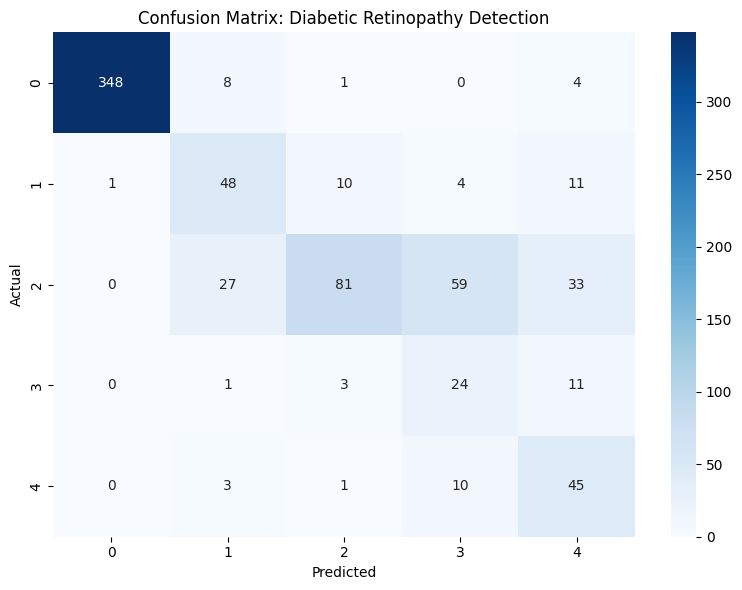

In [32]:
# ============================================================
# STEP 9. 성능 지표 확인 (QWK / Classification Report / Confusion Matrix)
# ============================================================

model.load_state_dict(torch.load('best_model_aptos.pt'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Quadratic Weighted Kappa (의료계 표준 지표)
qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
print(f"\n✅ Quadratic Weighted Kappa Score: {qwk:.4f}")
print("\n[Classification Report]")
print(classification_report(all_labels, all_preds,
                             target_names=['Grade 0','Grade 1','Grade 2',
                                           'Grade 3','Grade 4']))

# Confusion Matrix 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Diabetic Retinopathy Detection')
plt.tight_layout()
plt.show()



Grad-CAM 대상 이미지: 4a3da369b227  (4단계)
실제 진단: 4단계  |  모델 예측: 4단계


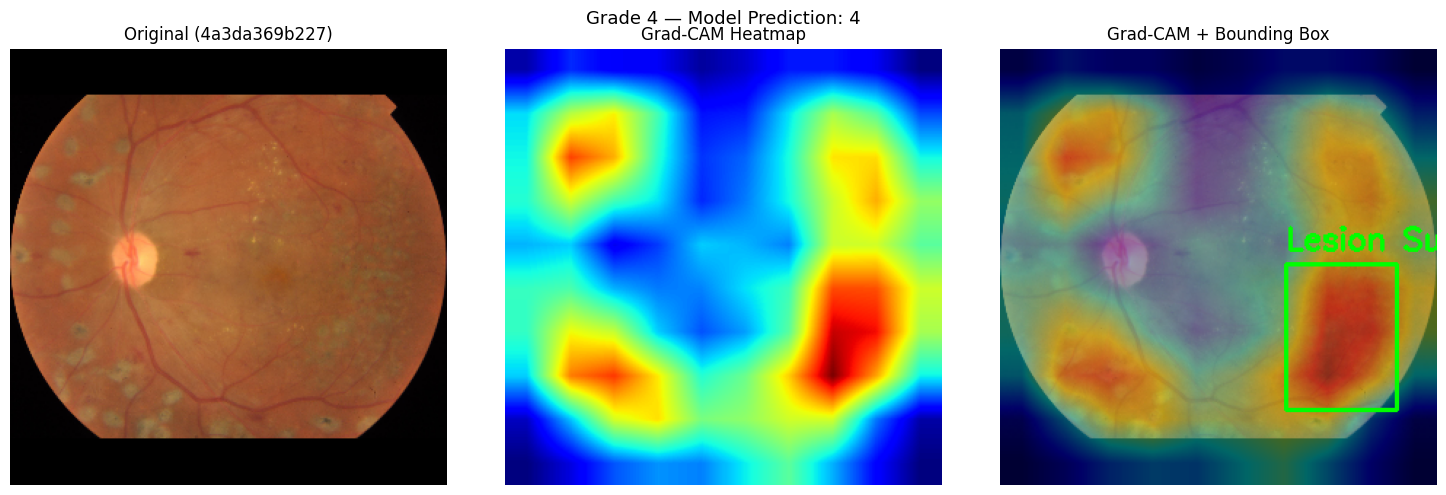

In [36]:
# ============================================================
# STEP 10. Grad-CAM 시각화 (모델 판단 근거 시각화)
# ============================================================

# val_df에서 4단계 샘플 하나 자동 선택
sample_row   = val_df[val_df['diagnosis'] == 4].iloc[0]
SAMPLE_ID    = sample_row['id_code']
IMG_PATH     = os.path.join(SAVE_DIR, SAMPLE_ID + '.png')
TARGET_CLASS = 4

print(f"\nGrad-CAM 대상 이미지: {SAMPLE_ID}  (4단계)")


class GradCAM:
    """선택된 모델의 마지막 특징 추출 층에서 Grad-CAM 생성 (EfficientNet / ResNet 공통 지원)"""
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        # register_backward_hook은 구조에 따라 grad_output[0]이 None이 될 수 있어
        # PyTorch 권장 API인 register_full_backward_hook으로 교체
        target_layer.register_full_backward_hook(self._save_gradient)
        target_layer.register_forward_hook(self._save_activation)

    def _save_gradient(self, module, grad_input, grad_output):
        # grad_output이 튜플로 반환되므로 None이 아닌 첫 번째 텐서를 안전하게 추출
        for g in grad_output:
            if g is not None:
                self.gradients = g.detach()
                break

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def generate(self, input_image, target_class=None):
        model_output = self.model(input_image)
        if target_class is None:
            target_class = torch.argmax(model_output)

        self.model.zero_grad()
        one_hot = torch.zeros_like(model_output)
        one_hot[0][target_class] = 1
        model_output.backward(gradient=one_hot, retain_graph=True)

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam     = torch.sum(weights * self.activations, dim=1).squeeze()
        cam     = np.maximum(cam.cpu().numpy(), 0)
        cam     = cv2.resize(cam, (input_image.shape[2], input_image.shape[3]))
        cam     = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam, model_output


model.eval()
# 선택된 모델에 따라 마지막 특징 추출 층 자동 지정
if hasattr(model, 'features'):   # EfficientNet 계열
    target_layer = model.features[8]
else:                             # ResNet 계열
    target_layer = model.layer4[-1]
grad_cam = GradCAM(model, target_layer)

original_img  = Image.open(IMG_PATH).convert('RGB')
input_tensor  = val_transform(original_img).unsqueeze(0).to(DEVICE)

cam, output   = grad_cam.generate(input_tensor, target_class=TARGET_CLASS)
_, pred_class = torch.max(output, 1)
print(f"실제 진단: {TARGET_CLASS}단계  |  모델 예측: {pred_class.item()}단계")

# 히트맵 합성 및 Bounding Box
img_bgr   = cv2.imread(IMG_PATH)
h, w, _   = img_bgr.shape
heatmap   = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap   = cv2.resize(heatmap, (w, h))
superimposed = cv2.addWeighted(img_bgr, 0.6, heatmap, 0.4, 0)

_, thresh = cv2.threshold(np.uint8(255 * cam), 178, 255, cv2.THRESH_BINARY)
thresh    = cv2.resize(thresh, (w, h))
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    cnt          = max(contours, key=cv2.contourArea)
    x, y, bw, bh = cv2.boundingRect(cnt)
    cv2.rectangle(superimposed, (x, y), (x+bw, y+bh), (0, 255, 0), 2)
    cv2.putText(superimposed, 'Lesion Suspect', (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title(f'Original ({SAMPLE_ID})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.title('Grad-CAM + Bounding Box')
plt.axis('off')

plt.suptitle(f'Grade {TARGET_CLASS} — Model Prediction: {pred_class.item()}', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# STEP 11. Baseline(전처리 전) 성능 비교
#
# 목적: '전처리 효과' 자체를 측정하기 위해
#       Baseline 모델도 Our Model과 동일한 에폭/조건으로 학습합니다.
#       단, 입력 이미지를 전처리 폴더(SAVE_DIR) 대신
#       원본 이미지 폴더(IMAGE_DIR)에서 단순 Resize만 적용하여 사용합니다.
#
#   Our Model  : 전처리 O (Ben Graham) + 동일 에폭 학습
#   Baseline   : 전처리 X (단순 Resize) + 동일 에폭 학습
#   → 두 결과의 차이 = 순수한 전처리 기여분
# ============================================================

print("\n" + "="*60)
print("  STEP 11: Baseline 학습 시작 (전처리 없는 원본 이미지)")
print("="*60)

# ── 전처리 없는 Transform (단순 Resize + Normalize) ──────────
baseline_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),   # 패딩 없이 강제 리사이즈 → 안구 왜곡 발생
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
baseline_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── 원본 이미지로 DataLoader 구성 ────────────────────────────
# Our Model과 동일한 train_df / val_df 분할 사용 (random_state=42 동일)
baseline_train_loader = DataLoader(
    APTOSDataset(train_df, IMAGE_DIR, baseline_train_transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
baseline_val_loader = DataLoader(
    APTOSDataset(val_df, IMAGE_DIR, baseline_val_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

# ── Baseline 모델 생성 (Our Model과 동일 아키텍처, ImageNet 가중치로 초기화) ──
if best_model_name == 'EfficientNet-B3':
    baseline_model = build_efficientnet_b3()
else:
    baseline_model = build_resnet50()

print(f"Baseline 아키텍처: {best_model_name}  (전처리 없는 원본 이미지로 학습)")

# ── Baseline 학습 (Our Model과 동일한 손실함수 / 옵티마이저 / 에폭 수) ──
baseline_optimizer = optim.AdamW(baseline_model.parameters(), lr=LR, weight_decay=1e-4)
baseline_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    baseline_optimizer, T_max=EPOCHS, eta_min=1e-6
)
baseline_scaler      = torch.amp.GradScaler('cuda')
baseline_best_loss   = float('inf')
baseline_patience    = 3
baseline_counter     = 0

# Backbone 고정 후 Head만 먼저 학습
for param in baseline_model.parameters():
    param.requires_grad = False
if hasattr(baseline_model, 'classifier'):
    for param in baseline_model.classifier.parameters():
        param.requires_grad = True
else:
    for param in baseline_model.fc.parameters():
        param.requires_grad = True

print("\nBaseline 학습 시작 (Backbone 고정 모드)\n")

baseline_val_qwk_history = []   # 최종 비교용 기록

for epoch in range(EPOCHS):
    # 5에폭 후 전체 Fine-tuning (Our Model과 동일한 시점)
    if epoch == 5:
        print("=> [Baseline] 5에폭 도달: 전체 파라미터 잠금 해제 (Fine-tuning 시작)")
        for param in baseline_model.parameters():
            param.requires_grad = True
        for pg in baseline_optimizer.param_groups:
            pg['lr'] = LR * 0.1

    # Train
    baseline_model.train()
    b_train_loss = 0.0
    for images, labels in baseline_train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        baseline_optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = baseline_model(images)
            loss    = criterion(outputs, labels)   # Our Model과 동일한 criterion 사용
        baseline_scaler.scale(loss).backward()
        baseline_scaler.step(baseline_optimizer)
        baseline_scaler.update()
        b_train_loss += loss.item() * images.size(0)

    # Validation
    baseline_model.eval()
    b_val_loss  = 0.0
    b_preds, b_labels = [], []
    with torch.no_grad():
        for images, labels in baseline_val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast():
                outputs = baseline_model(images)
                loss    = criterion(outputs, labels)
            b_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            b_preds.extend(preds.cpu().numpy())
            b_labels.extend(labels.cpu().numpy())

    b_avg_train = b_train_loss / len(baseline_train_loader.dataset)
    b_avg_val   = b_val_loss   / len(baseline_val_loader.dataset)
    b_qwk       = cohen_kappa_score(b_labels, b_preds, weights='quadratic')
    baseline_val_qwk_history.append(b_qwk)

    print(f"[Baseline] Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {b_avg_train:.4f} | Val Loss: {b_avg_val:.4f} | QWK: {b_qwk:.4f}")

    # 최적 모델 저장 및 Early Stopping
    if b_avg_val < baseline_best_loss:
        baseline_best_loss = b_avg_val
        torch.save(baseline_model.state_dict(), 'best_baseline_aptos.pt')
        print("  => [Baseline] 최고 성능 갱신! 모델 저장 완료")
        baseline_counter = 0
    else:
        baseline_counter += 1
        if baseline_counter >= baseline_patience:
            print(f"\n[Baseline] Early Stopping! (최저 Val Loss: {baseline_best_loss:.4f})")
            break

    baseline_scheduler.step()

# ── Baseline 최종 평가 (best checkpoint 기준) ─────────────────
baseline_model.load_state_dict(torch.load('best_baseline_aptos.pt'))
baseline_model.eval()

bp, bl = [], []
with torch.no_grad():
    for images, labels in baseline_val_loader:
        images = images.to(DEVICE)
        outputs = baseline_model(images)
        _, preds = torch.max(outputs, 1)
        bp.extend(preds.cpu().numpy())
        bl.extend(labels.numpy())

qwk_baseline = cohen_kappa_score(bl, bp, weights='quadratic')

print(f"\n[Baseline] Classification Report (전처리 없는 원본 이미지)")
print(classification_report(bl, bp,
                             target_names=['Grade 0','Grade 1','Grade 2',
                                           'Grade 3','Grade 4']))

# Baseline Confusion Matrix
cm_baseline = confusion_matrix(bl, bp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=range(5), yticklabels=range(5))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Baseline Confusion Matrix (전처리 없음)')
plt.tight_layout()
plt.show()

# Baseline 메모리 해제
del baseline_model
torch.cuda.empty_cache()
gc.collect()

# ── 최종 비교 요약 ────────────────────────────────────────────
print("\n" + "="*45)
print("        최종 성능 비교 (전처리 효과 측정)")
print("="*45)
print(f"  조건          | {'아키텍처':^16s} | QWK")
print("-"*45)
print(f"  전처리 X      | {best_model_name:^16s} | {qwk_baseline:.4f}")
print(f"  전처리 O      | {best_model_name:^16s} | {qwk:.4f}")
print("-"*45)
diff = qwk - qwk_baseline
sign = "+" if diff >= 0 else ""
print(f"  전처리 기여분 | {'':^16s} | {sign}{diff:.4f}")
print("="*45)



  STEP 11: Baseline 학습 시작 (전처리 없는 원본 이미지)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Baseline 아키텍처: ResNet-50  (전처리 없는 원본 이미지로 학습)

Baseline 학습 시작 (Backbone 고정 모드)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_1134/2256449428.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/2256449428.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[Baseline] Epoch  1/50 | Train Loss: 0.4397 | Val Loss: 0.3933 | QWK: 0.7560
  => [Baseline] 최고 성능 갱신! 모델 저장 완료


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_1134/2256449428.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/2256449428.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[Baseline] Epoch 14/50 | Train Loss: 0.1268 | Val Loss: 0.3265 | QWK: 0.8790


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_1134/2256449428.py:92: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_1134/2256449428.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1134/2256449428.py", line 105, in <cell line: 0>
    for images, labels in baseline_val_loader:
                          ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1524, in _next_data
    idx, data = self._get_data()
                ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1473, in _get_data
    success, data = self._try_get_data()
                    ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1310, in _try_get_data
    data = 

TypeError: object of type 'NoneType' has no len()